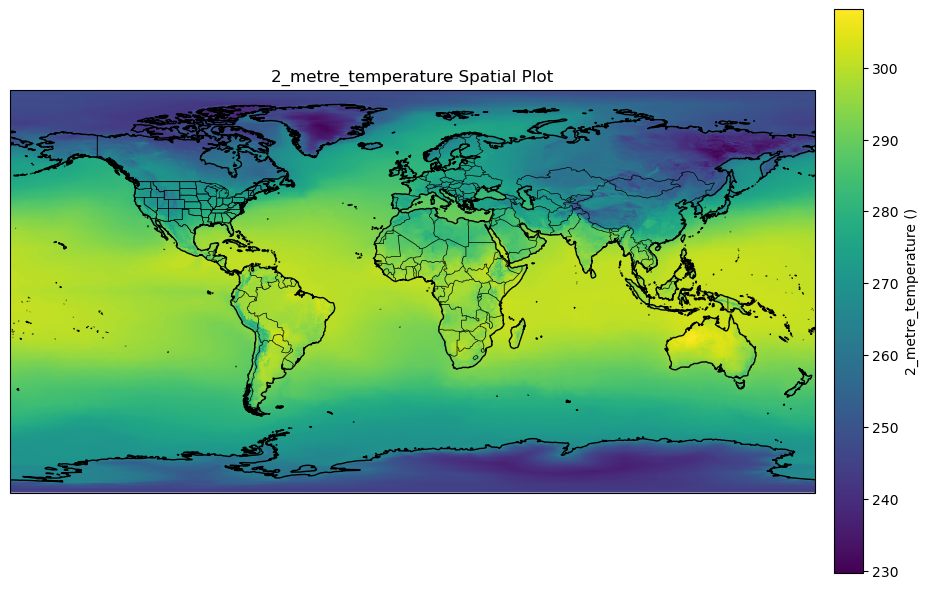

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

filename = "/Users/ljob/Downloads/cfsa_201112_mean.nc"
variable = "2_metre_temperature"

ds = xr.open_dataset(filename)
data = ds[variable]
lats = ds["lat"]
lons = ds["lon"]

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

plot = ax.pcolormesh(
    lons,
    lats,
    data,
    transform=ccrs.PlateCarree(),
    shading="auto"
)

# Add map features
ax.coastlines(resolution="50m")
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.4)

# Colorbar
cbar = plt.colorbar(plot, ax=ax, pad=0.02)
cbar.set_label(f"{variable} ({data.attrs.get('units', '')})")

# Title
ax.set_title(f"{variable} Spatial Plot")

plt.tight_layout()
plt.show()

/opt/miniconda3/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


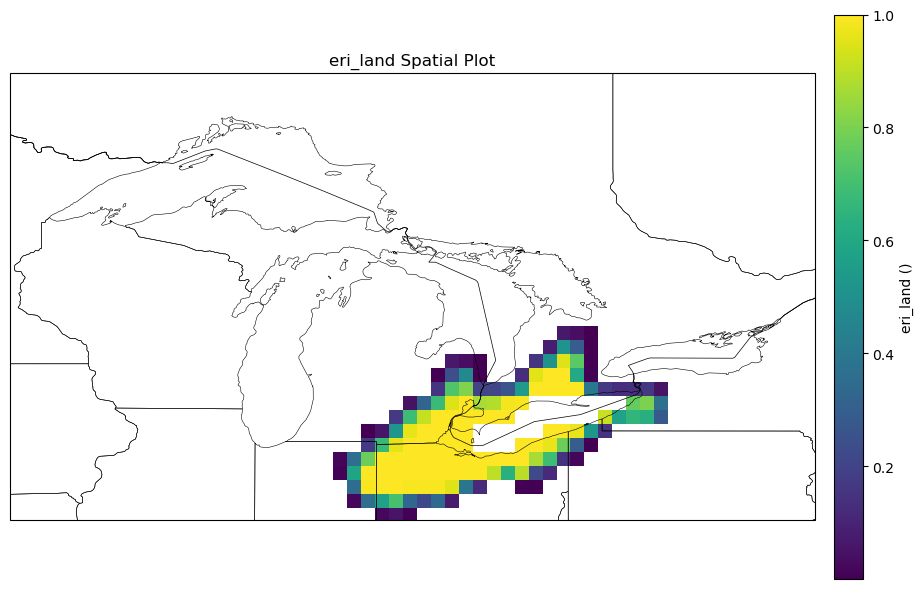

In [11]:
mask_file = '/Users/ljob/Desktop/Data/GL_mask.nc'
variable = 'eri_land'

mask_ds = xr.open_dataset(mask_file)
mask = mask_ds[variable]
lat = mask_ds['latitude']
lon = mask_ds['longitude']

lat_min, lat_max = 40.0, 50.0
lon_min, lon_max = -93.0, -75.0

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

plot = ax.pcolormesh(
    lon,
    lat,
    mask,
    transform=ccrs.PlateCarree(),
    shading="auto"
)

# Add map features
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.coastlines(resolution="50m")
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.4)

# Colorbar
cbar = plt.colorbar(plot, ax=ax, pad=0.02)
cbar.set_label(f"{variable} ({data.attrs.get('units', '')})")

# Title
ax.set_title(f"{variable} Spatial Plot")

plt.tight_layout()
plt.show()